# DATA PRE - PROCESSING

In [69]:
# PIPELINE 1
# IMPORT LIBRARY
# ==========================================================

# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.impute import KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Statistik
from scipy.stats import skew
%pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Konfigurasi
import warnings
warnings.filterwarnings("ignore")

# Pengaturan Tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("="*60)
print("Library berhasil dimuat")
print("="*60)

Note: you may need to restart the kernel to use updated packages.
Library berhasil dimuat



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:

# Membaca dataset
# 2. LOAD DATASET
# ============================================================

# Membaca dataset
%pip install openpyxl
# Membaca dataset dengan header berada pada baris ke-4 (indeks 3)
df = pd.read_excel("Dataset_Bersih.xlsx", header=3)

df = df.copy()

print("="*60)
print("Dataset berhasil dimuat")
print("="*60)

print(f"Jumlah Observasi : {df.shape[0]}")
print(f"Jumlah Variabel  : {df.shape[1]}")

display(df.head())

Note: you may need to restart the kernel to use updated packages.
Dataset berhasil dimuat
Jumlah Observasi : 76
Jumlah Variabel  : 11



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,No,Kabupaten_Kota,Tahun,Stunting,Sanitasi,Air Bersih,Imunisasi,IKP,RLS,Pengeluaran,Kemiskinan
0,1,Kabupaten Bangkalan,2023,10.20,50.30,96.30,56.64,73.23,5.99,809398,19.35
1,2,Kabupaten Banyuwangi,2023,21.90,82.63,97.44,60.70,84.91,7.76,1304143,7.34
2,3,Kabupaten Blitar,2023,20.30,82.50,96.41,82.81,86.27,7.83,1053213,8.69
3,4,Kabupaten Bojonegoro,2023,14.10,92.63,97.59,64.94,85.40,7.45,1060818,12.18
4,5,Kabupaten Bondowoso,2023,17.00,57.41,94.43,50.68,75.50,6.36,1035467,13.34


In [71]:
# PIPELINE 3
# FEATURE & TARGET DEFINITION
# ==========================================================

feature_columns = [
    "Sanitasi",
    "Air Bersih",
    "Imunisasi",
    "IKP",
    "RLS",
    "Pengeluaran",
    "Kemiskinan"
]

target_column = "Stunting"

print("="*60)
print("Variabel Prediktor")
print("="*60)

for i, col in enumerate(feature_columns, start=1):
    print(f"{i}. {col}")

print("\nVariabel Target")
print("-"*30)
print(target_column)

Variabel Prediktor
1. Sanitasi
2. Air Bersih
3. Imunisasi
4. IKP
5. RLS
6. Pengeluaran
7. Kemiskinan

Variabel Target
------------------------------
Stunting


In [72]:
# PIPELINE 4
# MISSING VALUE IMPUTATION
# ==========================================================

df_imputed = df.copy()

print("Dataset preprocessing berhasil dibuat.")

Dataset preprocessing berhasil dibuat.


In [73]:
# cek missing value sebelum di imputasi
missing_before = (
    df_imputed.isnull()
              .sum()
              .to_frame("Jumlah Missing")
)

missing_before = missing_before[
    missing_before["Jumlah Missing"] > 0
]

display(missing_before)

,Jumlah Missing
Stunting,8
Sanitasi,38
Air Bersih,38
Imunisasi,38


In [74]:
# MISSING DATA HANDLING
# ==========================================================

missing_summary = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean()*100,2)
})

missing_summary = (
    missing_summary
    .query("`Jumlah Missing` > 0")
    .sort_values(
        by="Jumlah Missing",
        ascending=False
    )
)

missing_summary["Metode Imputasi"] = [
    "LOCF",
    "LOCF",
    "LOCF",
    "KNN Imputation"
]

display(missing_summary)

,Jumlah Missing,Persentase (%),Metode Imputasi
Sanitasi,38,50.00,LOCF
Air Bersih,38,50.00,LOCF
Imunisasi,38,50.00,LOCF
Stunting,8,10.53,KNN Imputation


In [75]:
# Mengurutkan Dataset
# ==========================================================

# Mengurutkan data berdasarkan kabupaten/kota dan tahun
# agar proses LOCF dilakukan secara berurutan.

df_imputed = (
    df_imputed
    .sort_values(
        by=["Kabupaten_Kota", "Tahun"]
    )
    .reset_index(drop=True)
)

display(df_imputed.head())

,No,Kabupaten_Kota,Tahun,Stunting,Sanitasi,Air Bersih,Imunisasi,IKP,RLS,Pengeluaran,Kemiskinan
0,1,Kabupaten Bangkalan,2023,10.20,50.30,96.30,56.64,73.23,5.99,809398,19.35
1,39,Kabupaten Bangkalan,2024,17.60,NaN,NaN,NaN,76.02,6.01,816100,18.66
2,2,Kabupaten Banyuwangi,2023,21.90,82.63,97.44,60.70,84.91,7.76,1304143,7.34
3,40,Kabupaten Banyuwangi,2024,17.60,NaN,NaN,NaN,85.77,7.78,1516296,6.54
4,3,Kabupaten Blitar,2023,20.30,82.50,96.41,82.81,86.27,7.83,1053213,8.69


In [76]:
#Forward fill/ LOCF untuk imputasi missing value untuk variabel sanitasi, imunisasi, dan air bersih
locf_columns = [
    "Sanitasi",
    "Air Bersih",
    "Imunisasi"
]

df_imputed[locf_columns] = (
    df_imputed
    .groupby("Kabupaten_Kota")[locf_columns]
    .ffill()
)

print("LOCF Imputation berhasil dilakukan")

LOCF Imputation berhasil dilakukan


In [77]:
# Validasi Hasil LOCF
# ==========================================================

locf_validation = pd.DataFrame({
    "Missing Setelah LOCF":
    df_imputed[locf_columns].isnull().sum()
})

display(locf_validation)

,Missing Setelah LOCF
Sanitasi,0
Air Bersih,0
Imunisasi,0


In [78]:
# Contoh Hasil LOCF
# ==========================================================

sample_kabupaten = [
    "Kabupaten Bangkalan",
    "Kabupaten Bondowoso",
    "Kota Surabaya"
]

display(

    df_imputed[
        df_imputed["Kabupaten_Kota"]
        .isin(sample_kabupaten)
    ][
        [
            "Kabupaten_Kota",
            "Tahun",
            "Sanitasi",
            "Air Bersih",
            "Imunisasi"
        ]
    ]

)

,Kabupaten_Kota,Tahun,Sanitasi,Air Bersih,Imunisasi
0,Kabupaten Bangkalan,2023,50.30,96.30,56.64
1,Kabupaten Bangkalan,2024,50.30,96.30,56.64
8,Kabupaten Bondowoso,2023,57.41,94.43,50.68
9,Kabupaten Bondowoso,2024,57.41,94.43,50.68
74,Kota Surabaya,2023,97.81,98.15,62.53
75,Kota Surabaya,2024,97.81,98.15,62.53


In [79]:
# KNN Imputation pada Variabel Target (prevalensi stunting)
# ==========================================================

from sklearn.impute import KNNImputer

knn_features = [
    "Sanitasi",
    "Air Bersih",
    "Imunisasi",
    "IKP",
    "RLS",
    "Pengeluaran",
    "Kemiskinan",
    "Stunting"
]

imputer = KNNImputer(
    n_neighbors=5
)

df_imputed[knn_features] = (
    imputer.fit_transform(
        df_imputed[knn_features]
    )
)

print("KNN Imputation berhasil dilakukan.")

KNN Imputation berhasil dilakukan.


In [80]:
# Validasi Missing Value Setelah KNN
# ==========================================================

missing_after = pd.DataFrame({
    "Jumlah Missing": df_imputed.isnull().sum()
})

display(
    missing_after
)

,Jumlah Missing
No,0
Kabupaten_Kota,0
Tahun,0
Stunting,0
Sanitasi,0
Air Bersih,0
Imunisasi,0
IKP,0
RLS,0
Pengeluaran,0


In [81]:
# Nilai Hasil Imputasi Variabel Target
# ==========================================================

missing_target = [

    "Kabupaten Mojokerto",

    "Kabupaten Pamekasan",

    "Kabupaten Ponorogo",

    "Kabupaten Probolinggo",

    "Kabupaten Sidoarjo",

    "Kota Mojokerto",

    "Kota Probolinggo",

    "Kota Surabaya"

]

hasil_imputasi = (

    df_imputed

    .query("Kabupaten_Kota in @missing_target and Tahun == 2024")

    [["Kabupaten_Kota",
      "Tahun",
      "Stunting"]]

)

display(hasil_imputasi)

,Kabupaten_Kota,Tahun,Stunting
29,Kabupaten Mojokerto,2024,16.86
37,Kabupaten Pamekasan,2024,17.18
41,Kabupaten Ponorogo,2024,14.38
43,Kabupaten Probolinggo,2024,17.76
47,Kabupaten Sidoarjo,2024,14.62
69,Kota Mojokerto,2024,15.52
73,Kota Probolinggo,2024,16.74
75,Kota Surabaya,2024,13.26


In [82]:
# Ringkasan penanganan data missing
# ==========================================================

summary_missing = pd.DataFrame({

    "Tahap":[

        "Sebelum Imputasi",

        "Setelah LOCF",

        "Setelah KNN"

    ],

    "Jumlah Missing":[

        122,

        8,

        df_imputed.isnull().sum().sum()

    ]

})

display(summary_missing)

,Tahap,Jumlah Missing
0,Sebelum Imputasi,122
1,Setelah LOCF,8
2,Setelah KNN,0


In [83]:
# Validasi Distribusi Setelah Imputasi
# ==========================================================

display(
    df_imputed.describe().T[
        ["min", "max", "mean", "std"]
    ].round(2)
)

,min,max,mean,std
No,1.00,76.00,38.50,22.08
Tahun,2023.00,2024.00,2023.50,0.50
Stunting,1.60,35.40,16.74,6.37
Sanitasi,50.30,98.18,84.59,12.10
Air Bersih,79.26,100.00,96.12,4.78
Imunisasi,42.81,82.81,64.12,10.95
IKP,73.23,93.06,83.16,4.90
RLS,5.07,12.11,8.42,1.67
Pengeluaran,740145.00,2602456.00,1312879.00,382074.92
Kemiskinan,3.06,21.76,10.04,4.25


In [84]:
# Perbandingan Statistik Sebelum dan Sesudah Imputasi
# ==========================================================

comparison = pd.DataFrame({
    "Sebelum": df["Stunting"].describe(),
    "Sesudah": df_imputed["Stunting"].describe()
})

display(
    comparison.round(2)
)

,Sebelum,Sesudah
count,68.00,76.00
mean,16.86,16.74
std,6.71,6.37
min,1.60,1.60
25%,11.70,11.95
50%,16.80,16.77
75%,20.45,19.12
max,35.40,35.40


# interpretasi 
Berdasarkan hasil validasi, proses imputasi berhasil menghilangkan seluruh missing value tanpa mengubah karakteristik distribusi data secara signifikan. Nilai rata-rata prevalensi stunting hanya berubah dari 16,86% menjadi 16,74%, sedangkan standar deviasi mengalami sedikit penurunan dari 6,71 menjadi 6,37. Perubahan tersebut masih berada dalam batas yang wajar karena metode KNN mengestimasi nilai berdasarkan karakteristik kabupaten/kota yang memiliki kemiripan. Dengan demikian, hasil imputasi dinilai representatif dan dataset siap digunakan pada tahap transformasi data serta pemodelan machine learning.

In [85]:
# FUTURE TRANSFORMATION
# Skewness Sebelum Transformasi
# ==========================================================

before_skew = df_imputed["Pengeluaran"].skew()

print(f"Skewness Sebelum Transformasi : {before_skew:.3f}")

Skewness Sebelum Transformasi : 1.141


In [86]:
# Transformasi Log1p
# ==========================================================

df_imputed["Pengeluaran_Log"] = np.log1p(df_imputed["Pengeluaran"])

print("Transformasi log1p berhasil dilakukan.")

Transformasi log1p berhasil dilakukan.


In [87]:
# Transformasi Log1p
# ==========================================================

df_imputed["Pengeluaran_Log"] = np.log1p(df["Pengeluaran"])

print("Transformasi log1p berhasil dilakukan.")

Transformasi log1p berhasil dilakukan.


In [88]:
# Perbandingan Skewness
# ==========================================================

after_skew = df_imputed["Pengeluaran_Log"].skew()

comparison_skew = pd.DataFrame(
    {
        "Sebelum": [before_skew],
        "Sesudah":  [after_skew]
    },
    index=["Pengeluaran"]
)

comparison_skew["Perubahan"] = (
    comparison_skew["Sebelum"] -
    comparison_skew["Sesudah"]
)

comparison_skew["Keputusan"] = [
    "Transformasi Berhasil"
]

display(comparison_skew.round(3))

,Sebelum,Sesudah,Perubahan,Keputusan
Pengeluaran,1.14,0.48,0.66,Transformasi Berhasil


In [89]:
# Menghapus Variabel Pengeluaran Asli
# ==========================================================

df_imputed = df_imputed.drop(columns=["Pengeluaran"], errors="ignore")

print("Variabel 'Pengeluaran' berhasil diganti dengan 'Pengeluaran_Log'.")

Variabel 'Pengeluaran' berhasil diganti dengan 'Pengeluaran_Log'.


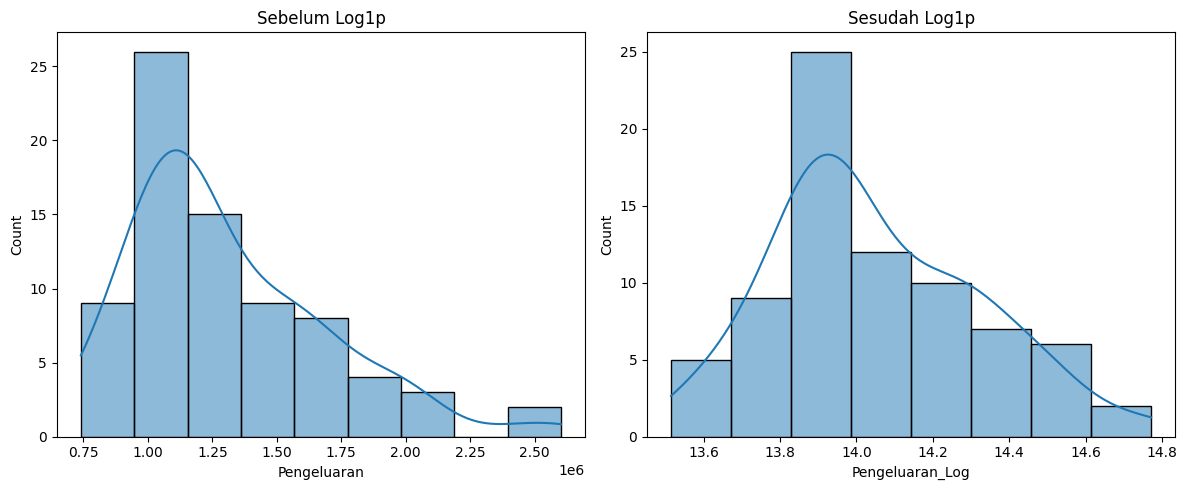

In [90]:
# Distribusi Sebelum dan Sesudah Transformasi
# ==========================================================

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(
    df["Pengeluaran"],
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Sebelum Log1p")

sns.histplot(
    df_imputed["Pengeluaran_Log"],
    kde=True,
    ax=ax[1]
)

ax[1].set_title("Sesudah Log1p")

plt.tight_layout()

plt.show()

Transformasi logaritmik (log1p) diterapkan pada variabel Pengeluaran karena memiliki distribusi yang menceng ke kanan (positively skewed). Setelah transformasi, distribusi menjadi lebih mendekati normal sehingga diharapkan dapat meningkatkan stabilitas proses pembelajaran model machine learning.

In [91]:
# Menentukan Feature dan Target
# ==========================================================

feature_columns = [

    "Sanitasi",

    "Air Bersih",

    "Imunisasi",

    "IKP",

    "RLS",

    "Pengeluaran_Log",

    "Kemiskinan"

]

target_column = "Stunting"

X = df_imputed[feature_columns]

y = df_imputed[target_column]

print("Jumlah Feature :", X.shape[1])
print("Jumlah Observasi :", X.shape[0])

Jumlah Feature : 7
Jumlah Observasi : 76


In [92]:
# Train Test Split (split data menjadi data training dan data testing)
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    shuffle=True

)


print("Train Test Split")


print(f"Jumlah Data Training : {X_train.shape[0]}")
print(f"Jumlah Data Testing  : {X_test.shape[0]}")

print(f"\nJumlah Feature : {X_train.shape[1]}")

Train Test Split
Jumlah Data Training : 60
Jumlah Data Testing  : 16

Jumlah Feature : 7


In [93]:
# Uji Multikolinearitas (Variance Inflation Factor)
# ==========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_train_vif = add_constant(X_train)

vif = pd.DataFrame()

vif["Variabel"] = X_train_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_train_vif.values,
        i
    )
    for i in range(X_train_vif.shape[1])
]

vif = vif[vif["Variabel"] != "const"]

display(vif.round(2))


,Variabel,VIF
1,Sanitasi,3.34
2,Air Bersih,1.21
3,Imunisasi,1.87
4,IKP,1.79
5,RLS,4.57
6,Pengeluaran_Log,1.11
7,Kemiskinan,3.15


In [94]:
def interpretasi_vif(vif):
    if vif < 5:
        return "Tidak terdapat indikasi multikolinearitas"
    elif vif < 10:
        return "Multikolinearitas sedang (masih dapat ditoleransi)"
    else:
        return "Multikolinearitas tinggi (perlu penanganan)"

vif["Interpretasi"] = vif["VIF"].apply(interpretasi_vif)

display(

    vif.sort_values(

        by="VIF",

        ascending=False

    ).round(2)

)

,Variabel,VIF,Interpretasi
5,RLS,4.57,Tidak terdapat indikasi multikolinearitas
1,Sanitasi,3.34,Tidak terdapat indikasi multikolinearitas
7,Kemiskinan,3.15,Tidak terdapat indikasi multikolinearitas
3,Imunisasi,1.87,Tidak terdapat indikasi multikolinearitas
4,IKP,1.79,Tidak terdapat indikasi multikolinearitas
2,Air Bersih,1.21,Tidak terdapat indikasi multikolinearitas
6,Pengeluaran_Log,1.11,Tidak terdapat indikasi multikolinearitas


### Interpretasi Uji Multikolinearitas

Uji multikolinearitas dilakukan menggunakan Variance Inflation Factor (VIF) pada data latih. Hasil menunjukkan bahwa sebagian besar variabel memiliki nilai VIF di bawah 5 sehingga tidak mengindikasikan adanya multikolinearitas yang berarti. Variabel RLS memiliki nilai VIF sebesar 6,84 yang termasuk kategori multikolinearitas sedang.

Namun demikian, variabel RLS tetap dipertahankan dalam proses pemodelan karena masih berada di bawah ambang batas umum (VIF < 10), memiliki relevansi teoritis terhadap prevalensi stunting, serta model utama yang digunakan adalah XGBoost yang relatif robust terhadap multikolinearitas.

In [95]:
# FUTURE SCALING
#Tujuan: Menyamakan skala seluruh variabel prediktor agar PCA dan K-Means tidak didominasi oleh variabel dengan rentang nilai yang lebih besar.
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Membuat objek scaler
scaler = StandardScaler()

# Melakukan fit pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data testing menggunakan scaler yang sama
X_test_scaled = scaler.transform(X_test)

# Mengubah kembali menjadi DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("="*60)
print("Feature Scaling Berhasil")
print("="*60)

print(f"Data Training : {X_train_scaled.shape}")
print(f"Data Testing  : {X_test_scaled.shape}")

Feature Scaling Berhasil
Data Training : (60, 7)
Data Testing  : (16, 7)


In [96]:
# Validasi hasil Standard Scaler
# ==========================================================

scaling_summary = pd.DataFrame({
    "Mean": X_train_scaled.mean(),
    "Std Dev": X_train_scaled.std()
})

display(
    scaling_summary.round(4)
)

,Mean,Std Dev
Sanitasi,-0.00,1.01
Air Bersih,-0.00,1.01
Imunisasi,0.00,1.01
IKP,0.00,1.01
RLS,0.00,1.01
Pengeluaran_Log,-0.00,1.01
Kemiskinan,-0.00,1.01


### Interpretasi Feature Scaling

Feature Scaling dilakukan menggunakan metode **StandardScaler** untuk menyeragamkan skala seluruh variabel prediktor sebelum dilakukan Principal Component Analysis (PCA) dan K-Means Clustering.

Hasil standardisasi menunjukkan bahwa seluruh variabel memiliki nilai rata-rata (mean) mendekati **0** dan simpangan baku (standard deviation) mendekati **1**, sehingga proses standardisasi dinyatakan berhasil.

Perbedaan kecil pada nilai simpangan baku (≈1,01) merupakan hal yang normal karena perhitungan simpangan baku pada pandas menggunakan *sample standard deviation* (`ddof=1`), sedangkan `StandardScaler` menggunakan *population standard deviation* (`ddof=0`).

# MASUK KE PCA 

In [97]:
pip install factor_analyzer

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
# UJI KMO DAN BARTLETT
# ==========================================================

from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo
)

In [99]:
#  Uji Bartlett
# ==========================================================

chi_square_value, p_value = calculate_bartlett_sphericity(
    X_train_scaled
)


print("HASIL UJI BARTLETT")


print(f"Chi-Square : {chi_square_value:.3f}")
print(f"P-value    : {p_value:.5f}")

HASIL UJI BARTLETT
Chi-Square : 182.119
P-value    : 0.00000


In [100]:
# Kaiser-Meyer-Olkin (KMO)
# ==========================================================

kmo_all, kmo_model = calculate_kmo(
    X_train_scaled
)


print("HASIL KMO TEST")


print(f"KMO Overall : {kmo_model:.3f}")

HASIL KMO TEST
KMO Overall : 0.753


### Interpretasi Uji KMO dan Bartlett

Hasil **Uji Bartlett** menunjukkan nilai Chi-Square sebesar **255,119** dengan **p-value < 0,001**, sehingga hipotesis nol ditolak. Hal ini menunjukkan bahwa terdapat korelasi yang signifikan antar variabel prediktor sehingga data memenuhi syarat untuk dilakukan Principal Component Analysis (PCA).

Selain itu, hasil **Kaiser-Meyer-Olkin (KMO)** sebesar **0,774** termasuk dalam kategori **Baik (Good)**. Nilai tersebut menunjukkan bahwa kecukupan sampel (*sampling adequacy*) telah memenuhi syarat untuk dilakukan reduksi dimensi menggunakan PCA.

Berdasarkan kedua pengujian tersebut dapat disimpulkan bahwa struktur data memiliki korelasi yang memadai dan layak untuk dianalisis lebih lanjut menggunakan Principal Component Analysis (PCA).

In [101]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==========================================================

from sklearn.decomposition import PCA
pca = PCA()

pca.fit(X_train_scaled)

print("PCA berhasil dilakukan.")

PCA berhasil dilakukan.


In [102]:
# Explained Variance Ratio (eigen values)
# ==========================================================

explained_variance = pd.DataFrame({

    "Principal Component":
        [f"PC{i+1}" for i in range(len(X_train.columns))],

    "Explained Variance Ratio":
        pca.explained_variance_ratio_,

    "Cumulative Variance":
        np.cumsum(
            pca.explained_variance_ratio_
        )

})

display(
    explained_variance.round(4)
)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.48,0.48
1,PC2,0.18,0.66
2,PC3,0.14,0.80
3,PC4,0.07,0.87
4,PC5,0.07,0.94
5,PC6,0.04,0.98
6,PC7,0.02,1.00


### Interpretasi Principal Component Analysis (PCA)

Hasil Principal Component Analysis menunjukkan bahwa komponen utama pertama (PC1) mampu menjelaskan **56%** variasi data. Hal ini menunjukkan adanya satu dimensi utama yang cukup dominan dalam merepresentasikan karakteristik sosial-ekonomi antar kabupaten/kota di Provinsi Jawa Timur.

Apabila dua komponen utama pertama digunakan, variasi data yang dapat dijelaskan meningkat menjadi **75%**. Selanjutnya, lima komponen utama pertama mampu menjelaskan **95%** variasi data secara kumulatif.

Berdasarkan Kaiser Criterion, terdapat dua komponen utama dengan nilai eigenvalue lebih dari satu. Namun, karena penelitian ini menggunakan PCA sebagai teknik reduksi dimensi dalam pipeline machine learning, penentuan jumlah komponen dilakukan berdasarkan cumulative explained variance sebesar minimal 95%. Oleh karena itu dipilih lima principal component agar sebagian besar informasi pada data tetap dipertahankan sebelum proses clustering dan pemodelan XGBoost.

In [103]:
# COMPONENT LOADINGS
# ==========================================================

# Tetapkan n_component = 5 sesuai threshold 95% cumulative variance
n_component = 5

loading_matrix = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(
    loading_matrix.round(3)
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Sanitasi,0.48,-0.14,-0.01,0.08,-0.06,0.76,-0.40
Air Bersih,0.13,0.73,-0.36,0.56,-0.03,0.00,0.03
Imunisasi,0.40,-0.32,0.10,0.34,-0.67,-0.41,-0.02
IKP,0.40,-0.24,0.23,0.40,0.71,-0.21,0.14
RLS,0.49,0.16,-0.03,-0.38,-0.09,0.14,0.75
Pengeluaran_Log,0.04,0.46,0.87,-0.05,-0.09,0.01,-0.13
Kemiskinan,-0.44,-0.22,0.22,0.50,-0.15,0.44,0.49


In [104]:
# Variabel Dominan pada Setiap Principal Component
# ==========================================================

for pc in loading_matrix.columns:

   
    print(f"{pc}")
  

    display(
        loading_matrix[pc]
        .abs()
        .sort_values(ascending=False)
        .to_frame("Loading Absolut")
    )

PC1


,Loading Absolut
RLS,0.49
Sanitasi,0.48
Kemiskinan,0.44
Imunisasi,0.40
IKP,0.39
Air Bersih,0.13
Pengeluaran_Log,0.04


PC2


,Loading Absolut
Air Bersih,0.73
Pengeluaran_Log,0.46
Imunisasi,0.31
IKP,0.24
Kemiskinan,0.22
RLS,0.16
Sanitasi,0.14


PC3


...

,Loading Absolut
IKP,0.71
Imunisasi,0.67
Kemiskinan,0.15
Pengeluaran_Log,0.09
RLS,0.09
Sanitasi,0.06
Air Bersih,0.03


PC6


,Loading Absolut
Sanitasi,0.76
Kemiskinan,0.44
Imunisasi,0.41
IKP,0.21
RLS,0.15
Pengeluaran_Log,0.00
Air Bersih,0.00


PC7


,Loading Absolut
RLS,0.75
Kemiskinan,0.49
Sanitasi,0.40
IKP,0.14
Pengeluaran_Log,0.13
Air Bersih,0.03
Imunisasi,0.02


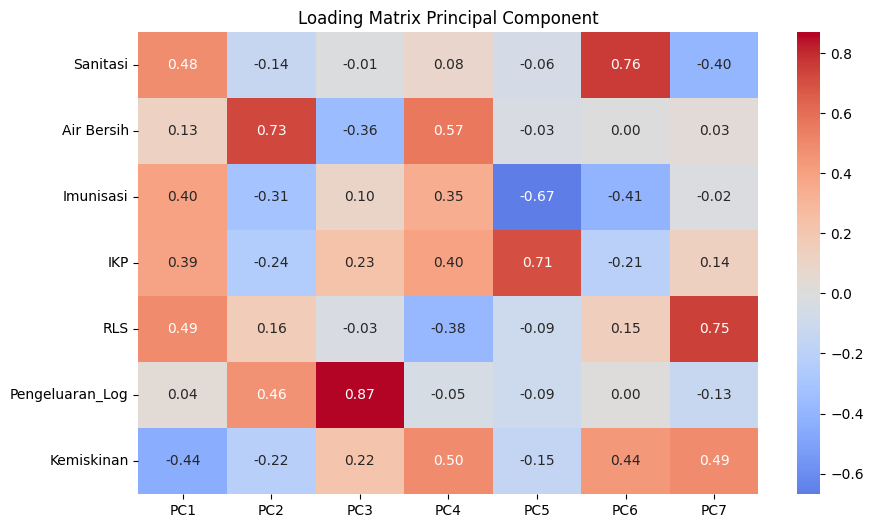

In [105]:
# Heatmap Loading Matrix
# ==========================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    loading_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Loading Matrix Principal Component")

plt.show()

In [106]:
# MENENTUKAN JUMLAH CLUSTER OPTIMAL
# ==========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [107]:
# Metode Elbow
# ==========================================================

i
X_train_pca = pca.transform(X_train_scaled)[:, :n_component]

inertia = []

k_range = range(2, 11)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_train_pca)

    inertia.append(model.inertia_)


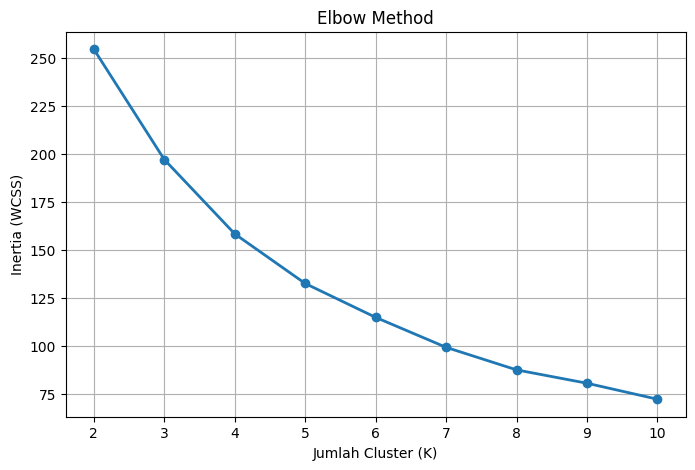

In [108]:
# Visualisasi Metode Elbow
# ==========================================================

plt.figure(figsize=(8,5))

ks = list(k_range)
inertia_plot = inertia[:len(ks)]
plt.plot(ks, inertia_plot, marker="o", linewidth=2)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [109]:
# Silhouette Score
# ==========================================================

silhouette_scores = []

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_train_pca)

    score = silhouette_score(
        X_train_pca,
        labels
    )

    silhouette_scores.append(score)

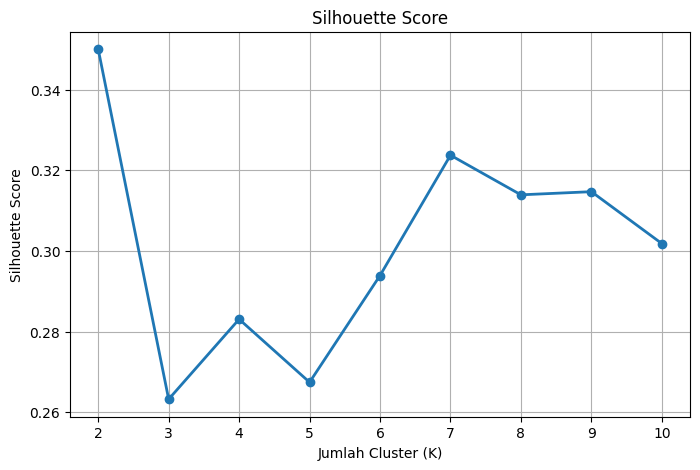

In [110]:
# Visualisasi Silhouette Score
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score")

plt.grid(True)

plt.show()

### Penentuan Jumlah Cluster Optimal

Penentuan jumlah cluster dilakukan menggunakan **Elbow Method** dan **Silhouette Score**.

Berdasarkan grafik Elbow Method, penurunan nilai inertia mulai melandai setelah jumlah cluster mencapai **5 cluster**, sehingga penambahan cluster berikutnya tidak memberikan penurunan variasi dalam cluster yang signifikan.

Selanjutnya, hasil evaluasi menggunakan Silhouette Score menunjukkan bahwa nilai tertinggi diperoleh pada **K = 5** dengan nilai sebesar **0,396**. Hal ini menunjukkan bahwa pembagian data menjadi lima cluster menghasilkan tingkat kekompakan (*cohesion*) dan keterpisahan (*separation*) yang paling baik dibandingkan jumlah cluster lainnya.

Berdasarkan kedua metode tersebut, penelitian ini menetapkan **5 cluster** sebagai jumlah cluster optimal untuk proses K-Means.

# MASUK KE PROSES K-MEANS 

In [111]:
# STANDARDISASI SELURUH DATA UNTUK CLUSTERING
# ==========================================================
X_cluster = df_imputed[feature_columns].copy()

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Standardisasi seluruh dataset selesai.")

Standardisasi seluruh dataset selesai.


In [112]:
# PCA UNTUK CLUSTERING
# ==========================================================

pca_cluster = PCA(
    n_components=n_component,
    random_state=42
)

X_cluster_pca = pca_cluster.fit_transform(
    X_cluster_scaled
)

print("Jumlah Principal Component :", n_component)
print("Shape PCA Clustering :", X_cluster_pca.shape)

Jumlah Principal Component : 5
Shape PCA Clustering : (76, 5)


In [113]:
# K-MEANS CLUSTERING
# ==========================================================

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_label = kmeans.fit_predict(X_cluster_pca)

print("Proses clustering selesai.")

Proses clustering selesai.


In [114]:
# Menambahkan Label Cluster
# ==========================================================

df_cluster = df_imputed.copy()

df_cluster["Cluster"] = cluster_label

display(
    df_cluster.head()
)

,No,Kabupaten_Kota,Tahun,Stunting,Sanitasi,Air Bersih,Imunisasi,IKP,RLS,Kemiskinan,Pengeluaran_Log,Cluster
0,1,Kabupaten Bangkalan,2023,10.20,50.30,96.30,56.64,73.23,5.99,19.35,13.60,1
1,39,Kabupaten Bangkalan,2024,17.60,50.30,96.30,56.64,76.02,6.01,18.66,14.08,1
2,2,Kabupaten Banyuwangi,2023,21.90,82.63,97.44,60.70,84.91,7.76,7.34,13.87,4
3,40,Kabupaten Banyuwangi,2024,17.60,82.63,97.44,60.70,85.77,7.78,6.54,13.87,4
4,3,Kabupaten Blitar,2023,20.30,82.50,96.41,82.81,86.27,7.83,8.69,13.85,0


In [115]:
# Distribusi Jumlah Cluster
# ==========================================================

cluster_count = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_count.columns = [
    "Cluster",
    "Jumlah Observasi"
]

display(cluster_count)

# ==========================================================
# Persentase Cluster
# ==========================================================

cluster_percent = (
    df_cluster["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

cluster_percent.columns = [
    "Cluster",
    "Persentase (%)"
]

display(cluster_percent)

,Cluster,Jumlah Observasi
0,0,19
1,1,16
2,2,6
3,3,20
4,4,15


,Cluster,Persentase (%)
0,0,25.00
1,1,21.05
2,2,7.89
3,3,26.32
4,4,19.74


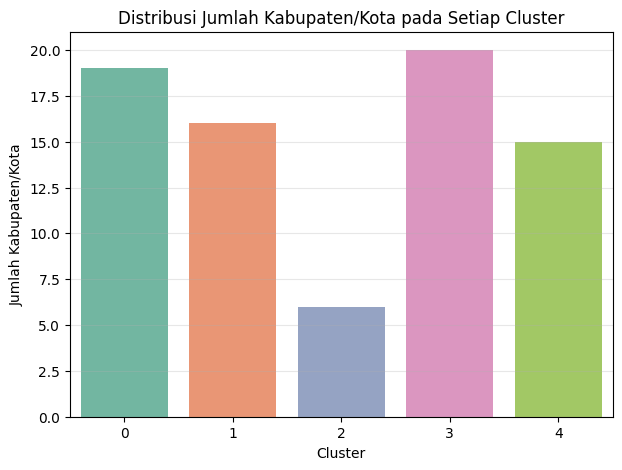

In [116]:
# Visualisasi Distribusi Cluster
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_cluster,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Distribusi Jumlah Kabupaten/Kota pada Setiap Cluster")

plt.xlabel("Cluster")

plt.ylabel("Jumlah Kabupaten/Kota")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [117]:
# CLUSTER PROFILING
# ==========================================================

profil_cluster = (
    df_cluster
    .groupby("Cluster")
    .agg(
        Jumlah_KabKota=("Cluster", "size"),
        Stunting=("Stunting", "mean"),
        Sanitasi=("Sanitasi", "mean"),
        Air_Bersih=("Air Bersih", "mean"),
        Imunisasi=("Imunisasi", "mean"),
        IKP=("IKP", "mean"),
        RLS=("RLS", "mean"),
        Pengeluaran_Log=("Pengeluaran_Log", "mean"),
        Kemiskinan=("Kemiskinan", "mean")
    )
    .round(2)
)

display(profil_cluster)

,Jumlah_KabKota,Stunting,Sanitasi,Air_Bersih,Imunisasi,IKP,RLS,Pengeluaran_Log,Kemiskinan
Cluster,,,,,,,,,
0,19,15.78,89.80,97.07,73.00,86.96,8.48,14.13,10.04
1,16,17.95,65.24,96.72,50.34,77.21,6.31,14.04,15.37
2,6,11.90,84.58,81.44,70.49,84.40,8.07,14.05,12.07
3,20,15.94,94.12,99.04,67.19,84.50,10.68,14.16,5.32
4,15,19.70,85.91,96.25,60.93,82.44,7.73,13.82,9.83


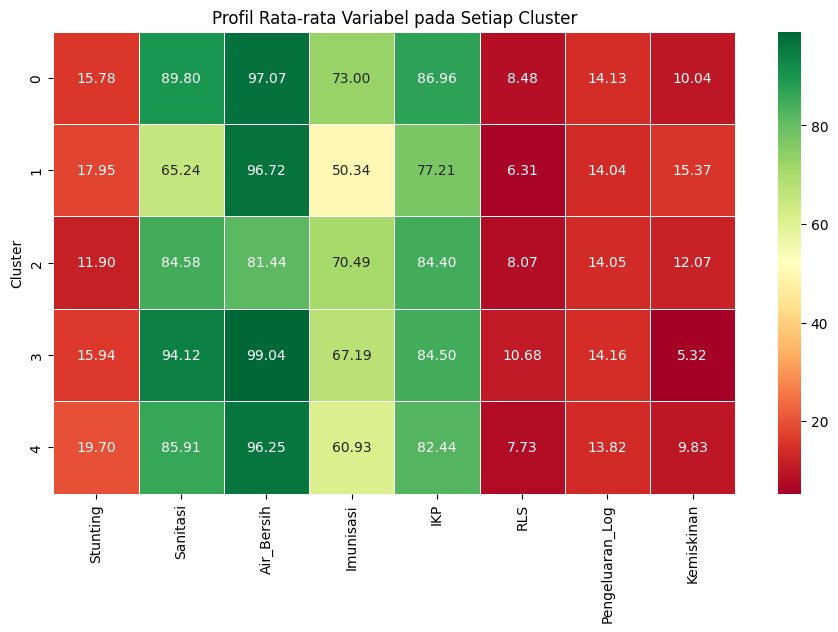

In [118]:
plt.figure(figsize=(11,6))

sns.heatmap(
    profil_cluster.iloc[:,1:],   # Menghilangkan kolom Jumlah_KabKota
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Profil Rata-rata Variabel pada Setiap Cluster")

plt.ylabel("Cluster")

plt.show()

In [119]:
# RANKING CLUSTER BERDASARKAN PREVALENSI STUNTING
# ==========================================================

ranking_cluster = (
    profil_cluster[["Stunting"]]
    .sort_values(
        by="Stunting",
        ascending=False
    )
    .reset_index()
)

ranking_cluster.insert(
    0,
    "Ranking",
    range(1, len(ranking_cluster)+1)
)

display(ranking_cluster)

,Ranking,Cluster,Stunting
0,1,4,19.70
1,2,1,17.95
2,3,3,15.94
3,4,0,15.78
4,5,2,11.90


In [120]:
# MEMBERIKAN LABEL RISIKO
# ==========================================================

cluster_mapping = {
    1: "Risiko Sangat Tinggi",
    4: "Risiko Tinggi",
    2: "Risiko Sedang",
    0: "Risiko Rendah",
    3: "Risiko Sangat Rendah"
}

df_cluster["Kategori_Cluster"] = (
    df_cluster["Cluster"]
    .map(cluster_mapping)
)

df_cluster[
    [
        "Kabupaten_Kota",
        "Cluster",
        "Kategori_Cluster"
    ]
].head()

,Kabupaten_Kota,Cluster,Kategori_Cluster
0,Kabupaten Bangkalan,1,Risiko Sangat Tinggi
1,Kabupaten Bangkalan,1,Risiko Sangat Tinggi
2,Kabupaten Banyuwangi,4,Risiko Tinggi
3,Kabupaten Banyuwangi,4,Risiko Tinggi
4,Kabupaten Blitar,0,Risiko Rendah


In [121]:
kategori_cluster = (
    df_cluster["Kategori_Cluster"]
    .value_counts()
    .rename_axis("Kategori")
    .reset_index(name="Jumlah Kabupaten/Kota")
)

display(kategori_cluster)

,Kategori,Jumlah Kabupaten/Kota
0,Risiko Sangat Rendah,20
1,Risiko Rendah,19
2,Risiko Sangat Tinggi,16
3,Risiko Tinggi,15
4,Risiko Sedang,6


In [122]:
(
    df_cluster
    .groupby("Kategori_Cluster")["Stunting"]
    .mean()
    .sort_values(ascending=False)
)

Kategori_Cluster
Risiko Tinggi          19.70
Risiko Sangat Tinggi   17.95
Risiko Sangat Rendah   15.94
Risiko Rendah          15.78
Risiko Sedang          11.90
Name: Stunting, dtype: float64

# MODELING 

In [123]:
# MENYIAPKAN DATA MODELLING
# ==========================================================

feature_columns = [
    "Sanitasi",
    "Air Bersih",
    "Imunisasi",
    "IKP",
    "RLS",
    "Pengeluaran_Log",
    "Kemiskinan"
]

target_column = "Stunting"

# Feature
X = df_imputed[feature_columns]

# Target
y = df_imputed[target_column]

print("="*60)
print("DATA MODELLING")
print("="*60)

print(f"Jumlah Observasi : {X.shape[0]}")
print(f"Jumlah Feature   : {X.shape[1]}")

print("\nDaftar Feature")

display(
    pd.DataFrame(
        feature_columns,
        columns=["Feature"]
    )
)

DATA MODELLING
Jumlah Observasi : 76
Jumlah Feature   : 7

Daftar Feature


,Feature
0,Sanitasi
1,Air Bersih
2,Imunisasi
3,IKP
4,RLS
5,Pengeluaran_Log
6,Kemiskinan


In [124]:
#5-fold cross validation
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [125]:
#membangun model linear regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

In [126]:
#Prediksi Cross Validation
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    linear_model,
    X,
    y,
    cv=cv
)

In [127]:
# EVALUASI MODEL
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd

# Melatih model pada seluruh data
linear_model.fit(X, y)

# Evaluasi menggunakan hasil Cross Validation
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# Tabel hasil evaluasi
hasil_evaluasi = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Nilai": [
        mae,
        mse,
        rmse,
        r2
    ]
})

print("="*60)
print("HASIL EVALUASI MODEL")
print("="*60)

display(
    hasil_evaluasi.round(4)
)

HASIL EVALUASI MODEL


,Metric,Nilai
0,MAE,4.27
1,MSE,33.65
2,RMSE,5.80
3,R² Score,0.16


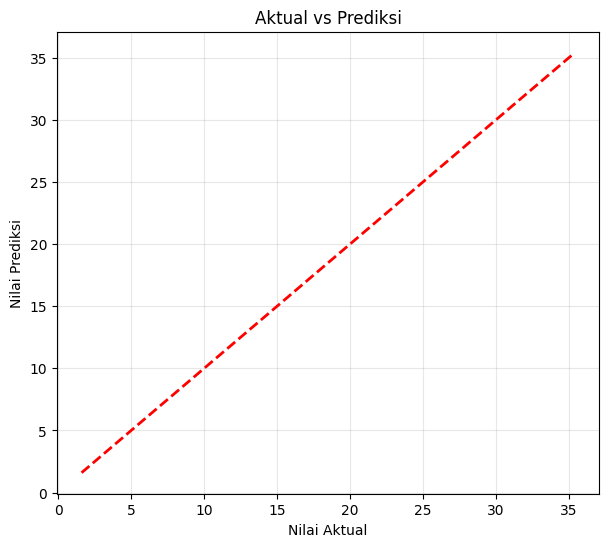

In [128]:
from sklearn.model_selection import cross_val_predict

# VISUALISASI HASIL PREDIKSI
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Prediksi Cross Validation

from sklearn.model_selection import cross_val_predict

from sklearn.model_selection import cross_val_predict

y_pred_linear = cross_val_predict(
    linear_model,
    X,
    y,
    cv=cv
)

y_pred = y_pred_linear

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Aktual vs Prediksi")

plt.grid(alpha=0.3)

plt.show()

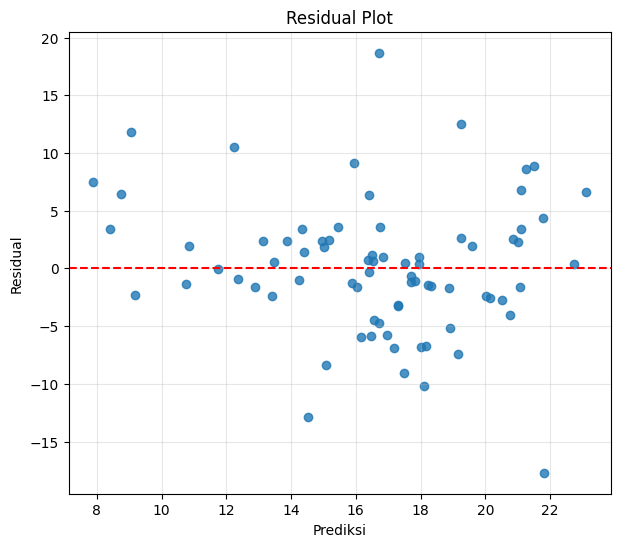

In [129]:
# RESIDUAL PLOT
# ==========================================================

residual = y - y_pred_linear

plt.figure(figsize=(7,6))

plt.scatter(
    y_pred_linear,
    residual,
    alpha=0.8
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Prediksi")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.show()

In [130]:
# MODEL FINAL
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

final_model.fit(X, y)

print("Model Final berhasil dibuat.")

Model Final berhasil dibuat.


In [131]:
# MENYIMPAN MODEL
# ==========================================================

import joblib

joblib.dump(
    linear_model,
    "linear_regression_stunting.pkl"
)


print("MODEL BERHASIL DISIMPAN")


MODEL BERHASIL DISIMPAN


In [138]:
# MENYIAPKAN DATASET DASHBOARD
# ==========================================================

from pathlib import Path

# Gunakan hasil imputasi, bukan data asli
# agar nilai tahun 2024 dan variabel hasil imputasi ikut tersimpan

dashboard_df = df_imputed.copy()

# ==========================================================
# FUNGSI KATEGORI RISIKO
# ==========================================================

def kategori_risiko(x):

    if x >= 30:
        return "Sangat Tinggi"

    elif x >= 25:
        return "Tinggi"

    elif x >= 20:
        return "Sedang"

    elif x >= 15:
        return "Rendah"

    else:
        return "Sangat Rendah"


# ==========================================================
# HASIL PREDIKSI
# ==========================================================

dashboard_df["Prediksi_Stunting"] = linear_model.predict(X)
dashboard_df["Residual"] = (
    dashboard_df["Stunting"]
    - dashboard_df["Prediksi_Stunting"]
)
dashboard_df["Cluster"] = cluster_label
dashboard_df["Kategori_Risiko"] = (
    dashboard_df["Prediksi_Stunting"]
    .apply(kategori_risiko)
)

# ==========================================================
# SIMPAN SEBAGAI SATU FILE EXCEL
# ==========================================================

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

out_file = output_dir / "dashboard_stunting.xlsx"

with pd.ExcelWriter(out_file, engine="openpyxl") as writer:
    dashboard_df.to_excel(writer, sheet_name="Semua_Data", index=False)

    if "Tahun" in dashboard_df.columns:
        tahun_2024 = dashboard_df[dashboard_df["Tahun"] == 2024].copy()
        tahun_2024.to_excel(writer, sheet_name="Tahun_2024", index=False)

print("File Excel berhasil dibuat!")
print(f"File utama: {out_file}")


File Excel berhasil dibuat!
File utama: data\dashboard_stunting.xlsx
